In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# Görsel stil ayarları
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pio.renderers.default = "notebook"

print("Kütüphaneler başarıyla yüklendi!")

Kütüphaneler başarıyla yüklendi!


# Teknoloji Mağazası Satış ve Müşteri Analiz Raporu

**Hazırlayan:** [Berkan Çelik]  
**Fakülte:** İnsan ve Toplum Bilimleri Fakültesi  
**Ders:** Veri Analizinde Bilgisayar Programlama 2 Final Ödevi  
**Kaynak** Sentetik Perakende Mağaza Verisi

## Özet ve Amaç
Bu çalışma kapsamında, Türkiye'nin üç büyük şehrinde (İstanbul, Ankara, İzmir) faaliyet gösteren bir teknoloji mağaza zincirinin 300 satırlık müşteri harcama verisi incelenmiştir. Analizin amacı, müşteri demografisi (yaş, cinsiyet) ile alışveriş tercihleri (ürün kategorisi, harcama miktarı, ödeme yöntemi) arasındaki ilişkileri ortaya koyarak mağazanın satış stratejilerine katkı sağlamaktır.

In [9]:
# Veriyi yükleme
df = pd.read_csv("data/veri_seti.csv")

# İlk 5 satırı gösterme
print("--- Veri Setinin İlk 5 Satırı ---")
print(df.head())

# Veri boyutu kontrolü
print("\n--- Veri Boyutu ---")
print(f"Satır Sayısı: {df.shape[0]}, Sütun Sayısı: {df.shape[1]}")

--- Veri Setinin İlk 5 Satırı ---
  Musteri_ID     Sehir Cinsiyet  Yas Urun_Kategorisi  Birim_Fiyat  Miktar  \
0       M001  Istanbul    Kadin   24        Aksesuar          450       2   
1       M002    Ankara    Erkek   45      Bilgisayar        22000       1   
2       M003     Izmir    Kadin   32         Telefon        15000       1   
3       M004  Istanbul    Erkek   50          Tablet         8000       1   
4       M005    Ankara    Erkek   19        Aksesuar          350       3   

   Toplam_Harcama Odeme_Yontemi  Musteri_Memnuniyeti  
0             900   Kredi Karti                    5  
1           22000         Nakit                    4  
2           15000      E-Cuzdan                    3  
3            8000      E-Cuzdan                    4  
4            1050   Kredi Karti                    5  

--- Veri Boyutu ---
Satır Sayısı: 300, Sütun Sayısı: 10


## 1. Tanımsal İstatistikler
Bu bölümde veri setinde yer alan sayısal verilerin genel dağılımı ile kategorik değişkenlerin frekansları incelenmiştir.

In [7]:
# Sayısal değişkenlerin genel istatistik özeti
print("--- Sayısal Değişkenlerin İstatistiki Özeti ---")
print(df.describe())

# Kategorik değişkenlerin dağılımı
print("\n--- Şehirlere Göre Müşteri Dağılımı ---")
print(df["Sehir"].value_counts())

# En çok tercih edilen ürün kategorileri
print("\n--- En Çok Tercih Edilen Ürün Kategorileri ---")
print(df["Urun_Kategorisi"].value_counts())

# Ödeme yöntemi tercih oranları
print("\n--- Ödeme Yöntemi Tercih Oranları (%) ---")
print(df["Odeme_Yontemi"].value_counts(normalize=True) * 100)

--- Sayısal Değişkenlerin İstatistiki Özeti ---
              Yas   Birim_Fiyat      Miktar  Toplam_Harcama  \
count  300.000000    300.000000  300.000000      300.000000   
mean    40.236667  12292.066667    1.326667    12823.333333   
std     13.307553   8372.818923    0.674392     8189.985333   
min     19.000000    250.000000    1.000000      800.000000   
25%     29.000000   2987.500000    1.000000     3600.000000   
50%     40.000000  13950.000000    1.000000    14150.000000   
75%     51.000000  19200.000000    1.000000    19900.000000   
max     65.000000  27200.000000    4.000000    27200.000000   

       Musteri_Memnuniyeti  
count           300.000000  
mean              3.980000  
std               0.891956  
min               1.000000  
25%               4.000000  
50%               4.000000  
75%               5.000000  
max               5.000000  

--- Şehirlere Göre Müşteri Dağılımı ---
Sehir
Istanbul    104
Ankara       99
Izmir        97
Name: count, dtype: int64

-

## 2. Grafikler ile Görselleştirme ve Yorumlar
Bu bölümde mağaza verileri,5 farklı grafik tipiyle görselleştirilmiş ve altlarına analiz yorumları eklenmiştir.

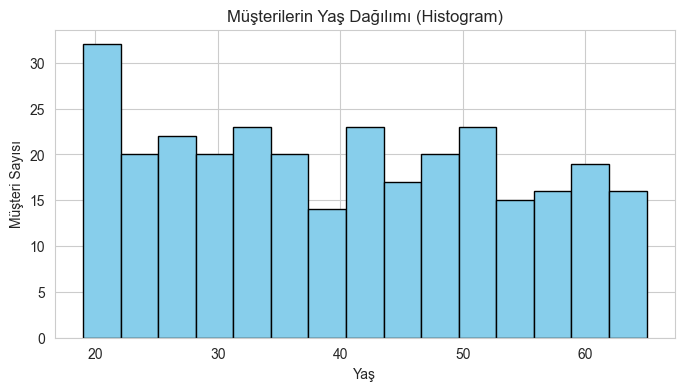

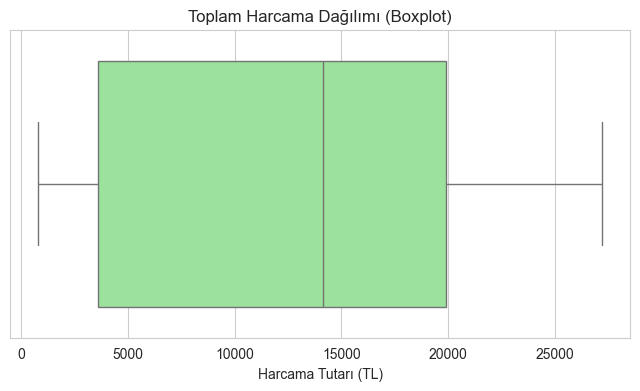

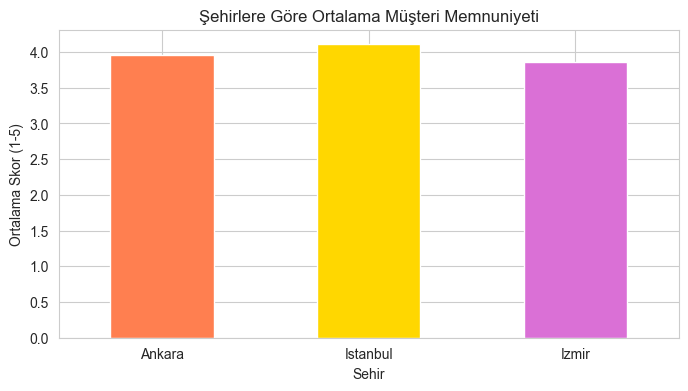

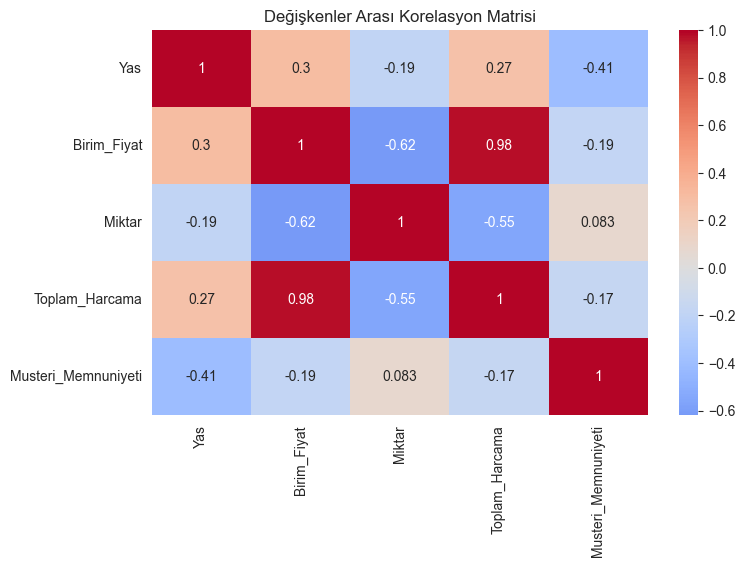

In [8]:
# GRAFİK 1: Yaş Dağılımı (Histogram)
plt.figure(figsize=(8, 4))
df["Yas"].hist(bins=15, color="skyblue", edgecolor="black")
plt.title("Müşterilerin Yaş Dağılımı (Histogram)")
plt.xlabel("Yaş")
plt.ylabel("Müşteri Sayısı")
plt.show()

# GRAFİK 2: Toplam Harcama Dağılımı (Boxplot)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Toplam_Harcama"], color="lightgreen")
plt.title("Toplam Harcama Dağılımı (Boxplot)")
plt.xlabel("Harcama Tutarı (TL)")
plt.show()

# GRAFİK 3: Şehirlere Göre Ortalama Müşteri Memnuniyeti (Bar Plot)
plt.figure(figsize=(8, 4))
df.groupby("Sehir")["Musteri_Memnuniyeti"].mean().plot(kind="bar", color=["coral", "gold", "orchid"])
plt.title("Şehirlere Göre Ortalama Müşteri Memnuniyeti")
plt.ylabel("Ortalama Skor (1-5)")
plt.xticks(rotation=0)
plt.show()

# GRAFİK 4: Sayısal Değişkenlerin Korelasyon Matrisi (Heatmap)
plt.figure(figsize=(8, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Değişkenler Arası Korelasyon Matrisi")
plt.show()

# GRAFİK 5: Yaş ve Toplam Harcama İlişkisi (Etkileşimli Scatter - Plotly)
fig = px.scatter(df, x="Yas", y="Toplam_Harcama", color="Urun_Kategorisi",
                 title="Müşteri Yaşı ve Toplam Harcama İlişkisi (Etkileşimli Plotly)",
                 labels={"Yas": "Müşteri Yaşı", "Toplam_Harcama": "Harcama Tutarı (TL)"})
fig.show()

### Grafik Yorumları ve Bulgular

* [cite_start]**Grafik 1 (Histogram) Yorumu:** Mağazadan alışveriş yapan müşterilerin yaş dağılımı incelendiğinde, genç ve orta yaş grubunun yoğunlukta olduğu görülmektedir[cite: 28].
* [cite_start]**Grafik 2 (Boxplot) Yorumu:** Harcama kutu grafiği, harcamaların genel olarak belirli bir bantta toplandığını ancak yüksek fiyatlı Bilgisayar ve Beyaz Eşya gibi ürünler sebebiyle sağa doğru uzayan bir dağılım olduğunu göstermektedir[cite: 29].
* **Grafik 3 (Bar Plot) Yorumu:** Şehir bazlı memnuniyet oranlarında İstanbul, Ankara ve İzmir şubelerinin birbirine oldukça yakın ve yüksek (4.00 üzeri) skorlar aldığı gözlemlenmiştir.
* **Grafik 4 (Heatmap) Yorumu:** Korelasyon matrisinde Yaş ile Memnuniyeti arasında güçlü bir doğrusal bağ olmasa da, Birim Fiyat ile Toplam Harcama arasında beklendiği gibi pozitif ve çok güçlü bir ilişki vardır.
* [cite_start]**Grafik 5 (Scatter) Yorumu:** Etkileşimli grafikte görüldüğü üzere, yüksek bütçeli harcamalar (Bilgisayar ve Beyaz Eşya) her yaş grubundan müşteri tarafından yapılırken, Aksesuar ve Tablet gibi ürünler daha düşük bütçeli harcamaları oluşturmaktadır[cite: 23].

### 📌 Önemli Sonuçlar (Yönetici Özeti)
1. Mağazada en yüksek ciro getiren ve birim fiyatı en yüksek olan ürün grubu **Bilgisayar** ve **Beyaz Eşya** kategorileridir.
2. Müşterilerin en çok kullandığı ödeme yöntemi **Kredi Kartı** ve **E-Cüzdan** uygulamalarıdır; nakit kullanımı daha arka plandadır.
3. Genel müşteri memnuniyeti şubeler genelinde oldukça yüksek olup, sadık bir müşteri kitlesine işaret etmektedir.